In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()

df = pd.DataFrame(
    data.data,
    columns = data.feature_names
)

df["target"] = data.target
print(df.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [2]:
print(df.shape)

(569, 31)


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [4]:
print(df["target"].value_counts())

target
1    357
0    212
Name: count, dtype: int64


In [5]:
print(df.isnull().sum())

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64


In [6]:
X = df.drop("target",axis = 1)

In [7]:
y = df["target"]

In [8]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

In [9]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    random_state=42
)

model.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

In [10]:
y_pred = model.predict(X_test)

In [11]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test,y_pred))

print("Precision:", precision_score(y_test,y_pred))

print("Recall :", recall_score(y_test,y_pred))

print("F1 :", f1_score(y_test,y_pred))

print(confusion_matrix(y_test,y_pred))

Accuracy : 0.9649122807017544
Precision: 0.958904109589041
Recall : 0.9859154929577465
F1 : 0.9722222222222222
[[40  3]
 [ 1 70]]


In [12]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

                 Feature  Importance
23            worst area    0.153892
27  worst concave points    0.144663
7    mean concave points    0.106210
20          worst radius    0.077987
6         mean concavity    0.068001
22       worst perimeter    0.067115
2         mean perimeter    0.053270
0            mean radius    0.048703
3              mean area    0.047555
26       worst concavity    0.031802


In [13]:
print(model.n_estimators)

100


In [14]:
model = RandomForestClassifier(
    n_estimators = 100,
    oob_score = True,
    random_state = 42
)

model.fit(X_train,y_train)

print(model.oob_score_)

0.9560439560439561


In [15]:
model_hyperparameter_tuning =  RandomForestClassifier(
    n_estimators = 200,
    max_depth = 5,
    min_samples_split = 5,
    min_samples_leaf = 5,
    random_state = 42
)

model_hyperparameter_tuning.fit(
    X_train,
    y_train
)

RandomForestClassifier(max_depth=5, min_samples_leaf=5, min_samples_split=5,
                       n_estimators=200, random_state=42)

In [16]:
y_pred_tuning = model_hyperparameter_tuning.predict(X_test)

In [17]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test,y_pred_tuning))

print("Precision:", precision_score(y_test,y_pred_tuning))

print("Recall :", recall_score(y_test,y_pred_tuning))

print("F1 :", f1_score(y_test,y_pred_tuning))

print(confusion_matrix(y_test,y_pred_tuning))

Accuracy : 0.9649122807017544
Precision: 0.958904109589041
Recall : 0.9859154929577465
F1 : 0.9722222222222222
[[40  3]
 [ 1 70]]


In [18]:
print(model.get_params())

print(model_hyperparameter_tuning.get_params())

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': True, 'random_state': 42, 'verbose': 0, 'warm_start': False}
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 5, 'min_samples_split': 5, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [19]:
depths_default = [tree.tree_.max_depth for tree in model.estimators_]
depths_tuned = [tree.tree_.max_depth for tree in model_hyperparameter_tuning.estimators_]

print("Average depth (default):", sum(depths_default)/len(depths_default))
print("Average depth (tuned):", sum(depths_tuned)/len(depths_tuned))

Average depth (default): 7.26
Average depth (tuned): 4.915


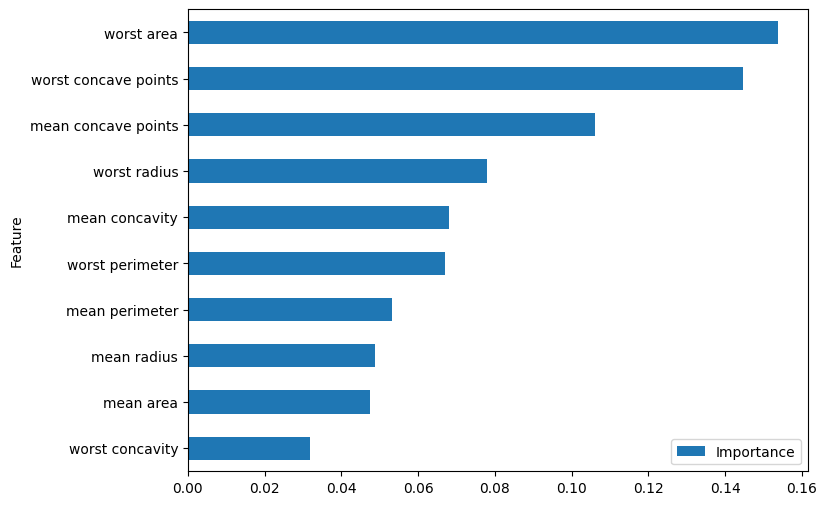

In [20]:
import matplotlib.pyplot as plt

importance.sort_values(
    by="Importance"
).tail(10).plot(

    x="Feature",

    y="Importance",

    kind="barh",

    figsize=(8,6)

)

plt.show()

In [21]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [10,50, 100, 200, 500],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}



In [22]:
grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring=scoring,
    refit="accuracy",   # Select the best model based on accuracy
    cv=5,
    return_train_score=True
)



In [23]:
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [None, 5, 10, 15],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [10, 50, 100, 200, 500]},
             refit='accuracy', return_train_score=True,
             scoring={'accuracy': 'accuracy', 'f1': 'f1',
                      'precision': 'precision', 'recall': 'recall'})

In [24]:
print(grid.best_params_)

{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [25]:
print(grid.best_score_)

0.9626373626373625


In [26]:
results = pd.DataFrame(grid.cv_results_)

print(results[[
    "mean_test_accuracy",
    "mean_test_precision",
    "mean_test_recall",
    "mean_test_f1"
]].head())

   mean_test_accuracy  mean_test_precision  mean_test_recall  mean_test_f1
0            0.931868             0.945357          0.947671      0.946194
1            0.953846             0.962287          0.965094      0.963502
2            0.958242             0.959423          0.975439      0.967129
3            0.962637             0.962813          0.978947      0.970578
4            0.960440             0.959649          0.978947      0.968927


In [27]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.9649122807017544
Precision: 0.958904109589041
Recall   : 0.9859154929577465
F1 Score : 0.9722222222222222


Why do the important features differ from Decision Tree? : 

The important features differ because a Decision Tree is built from a single tree, while a Random Forest combines many decision trees. The Random Forest computes feature importance by averaging the contribution of each feature across all trees, making its feature importance more stable and reliable.